# OLS Regression

**Data Science for Research Assistants**

This notebook introduces linear regression (Ordinary Least Squares) in Python. By the end, you'll be able to fit and interpret linear models with numerical and categorical predictors.

## How to Use This Notebook

- Run each cell by pressing `Shift + Enter`
- Feel free to modify the code and experiment
- If something breaks, you can restart the kernel from the menu and run cells again

---
## Setup

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline
sns.set_style("whitegrid")

---
## Loading the Data

We'll use the Star Wars characters dataset to explore linear regression.

In [2]:
starwars= pd.read_csv("../data/star_wars.csv", na_values="NA")

In [3]:
sw = starwars[
    (starwars["sex"].isin(["male", "female"])) &
    (starwars["mass"] < 500)
].dropna(subset=["height","mass"])

In [4]:
sw

,name,height,mass,hair_color,skin_color,eye_color,birth_year,sex,gender,homeworld,species,films,vehicles,starships
0,Luke Skywalker,172.0,77.0,blond,fair,blue,19.0,male,masculine,Tatooine,Human,"A New Hope, The Empire Strikes Back, Return of...","Snowspeeder, Imperial Speeder Bike","X-wing, Imperial shuttle"
3,Darth Vader,202.0,136.0,none,white,yellow,41.9,male,masculine,Tatooine,Human,"A New Hope, The Empire Strikes Back, Return of...",NaN,TIE Advanced x1
4,Leia Organa,150.0,49.0,brown,light,brown,19.0,female,feminine,Alderaan,Human,"A New Hope, The Empire Strikes Back, Return of...",Imperial Speeder Bike,NaN
5,Owen Lars,178.0,120.0,"brown, grey",light,blue,52.0,male,masculine,Tatooine,Human,"A New Hope, Attack of the Clones, Revenge of t...",NaN,NaN
6,Beru Whitesun Lars,165.0,75.0,brown,light,blue,47.0,female,feminine,Tatooine,Human,"A New Hope, Attack of the Clones, Revenge of t...",NaN,NaN
8,Biggs Darklighter,183.0,84.0,black,light,brown,24.0,male,masculine,Tatooine,Human,A New Hope,NaN,X-wing
9,Obi-Wan Kenobi,182.0,77.0,"auburn, white",fair,blue-gray,57.0,male,masculine,Stewjon,Human,"A New Hope, The Empire Strikes Back, Return of...",Tribubble bongo,"Jedi starfighter, Trade Federation cruiser, Na..."
10,Anakin Skywalker,188.0,84.0,blond,fair,blue,41.9,male,masculine,Tatooine,Human,"The Phantom Menace, Attack of the Clones, Reve...","Zephyr-G swoop bike, XJ-6 airspeeder","Naboo fighter, Trade Federation cruiser, Jedi ..."
12,Chewbacca,228.0,112.0,brown,unknown,blue,200.0,male,masculine,Kashyyyk,Wookiee,"A New Hope, The Empire Strikes Back, Return of...",AT-ST,"Millennium Falcon, Imperial shuttle"
13,Han Solo,180.0,80.0,brown,fair,brown,29.0,male,masculine,Corellia,Human,"A New Hope, The Empire Strikes Back, Return of...",NaN,"Millennium Falcon, Imperial shuttle"


We can already get a sneak peek of our aim with `sns.regplot` to display a _linear regression_ on top of our data points:

Text(0, 0.5, 'Mass (kg')

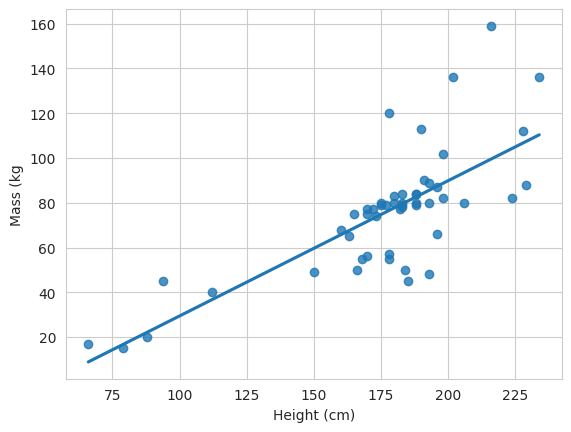

In [5]:
sns.regplot(data=sw, x="height", y="mass", ci= None)
plt.xlabel("Height (cm)")
plt.ylabel("Mass (kg")

---
## Models as Functions

A **linear model** represents the relationship between a response variable and one or more explanatory variables.

| Term | Definition |
|------|------------|
| Response variable (y) | Variable you want to predict or explain |
| Explanatory variable (x) | Variable used to predict the response |
| Predicted value ($\hat{y}$) | Model's estimate for a given x |
| Residual | Observed value - Predicted value |

---
## Fitting a Linear Model

In the previous plot we fit a linear relationship to our data with `sns.regplot` (Seaborn's regression plot method). But how can we get the function (i.e., the model) for this linear relationship?

We expect a relationship of the form:

$$\widehat{y} = b + m \times x$$

Where $b$ is the y-intercept, $m$ is the slope, $x$ is the explanatory variable, and $\widehat{y}$ is the predicted value based on available response variable data $y$.

So, if we wanted to know "how does height affect mass?", we need to resolve $b$ and $m$ in:

$$\widehat{mass} = b + m \times height$$

The way we do that is by minimizing the residuals between the response variable and the function that describes the linear relationship:

![Linear least squares](figures/Linear_least_squares_example2.png)

_A plot of the data points (in red), the least squares line of best fit (in blue), and the residuals (in green)_


---
## Aside: Installing a package

For the next step, we'll need another Python package, which we neglected to install in the codespace environment: [statsmodels](https://www.statsmodels.org/stable/index.html)

Try running this cell:

In [6]:
import statsmodels.formula.api as smf

You should get an error, since the package is not installed in the codespace (i.e. it is not installed in this mini-computer we're renting from GitHub).

To install the package, we can use Python's package manager [pip](https://pip.pypa.io/en/latest/).

In the terminal pane, you could run:

```
$ pip install statsmodels
```

However, since we're in a Jupyter Notebook, we can also use another special command:

In [7]:
!pip install statsmodels

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


If you run that line in a Jupyter notebook cell, it will install the statsmodels package in your current Python environment.

The `!` exclamation at the beginning of the line is our way of saying: "run this cell in the terminal bash prompt, not in the Python kernel."

Now we can import that package and continue:

In [8]:
import statsmodels.formula.api as smf

---
## Least Squares Regression with `statsmodels`

In practical terms, we can accomplish ordinary least squares regression using `smf.ols()` from statsmodels to fit a linear model.

The formula syntax is: `'y ~ x'`:

In [9]:
model1=smf.ols("mass ~ height", data=sw).fit()
model1.params

Intercept   -30.973807
height        0.603959
dtype: float64

The model equation is:

$$\widehat{mass} = -31.0 + 0.60 \times height$$

### Interpreting Coefficients

- **Slope (0.60)**: For each additional cm in height, mass increases by 0.60 kg on average
- **Intercept (-31.0)**: The predicted mass when height = 0 (not meaningful here)

In [10]:
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                   mass   R-squared:                       0.564
Model:                            OLS   Adj. R-squared:                  0.555
Method:                 Least Squares   F-statistic:                     63.40
Date:                Sun, 19 Apr 2026   Prob (F-statistic):           2.18e-10
Time:                        21:37:57   Log-Likelihood:                -220.37
No. Observations:                  51   AIC:                             444.7
Df Residuals:                      49   BIC:                             448.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -30.9738     13.650     -2.269      0.0

We can also plot the results using another statsmodels library:

In [11]:
import statsmodels.graphics.api as smg


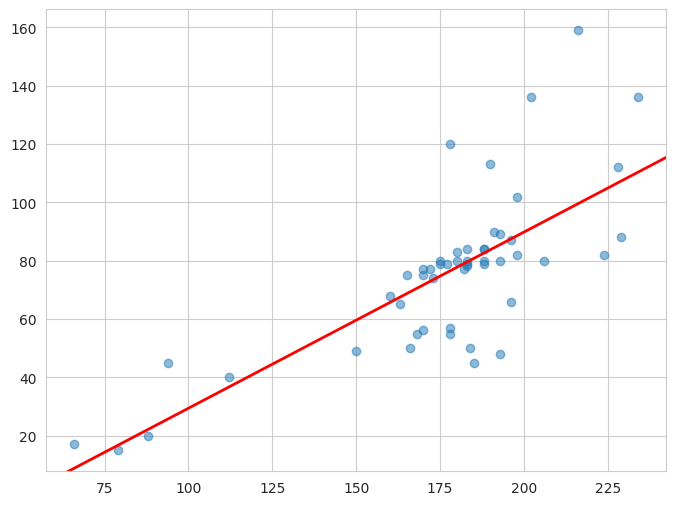

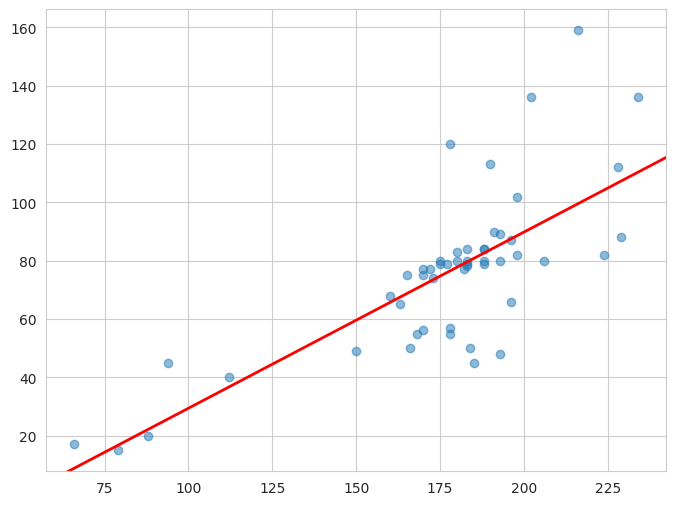

In [12]:
plt.figure(figsize=(8,6))
plt.scatter(sw['height'], sw['mass'], alpha=0.5)
smg.abline_plot(model_results=model1, ax=plt.gca(), color="red", linewidth=2)

---
## Categorical Predictors

Linear models with continuous, numerical variables like height and mass are relatively straightforward to fit.

But what happens when you have _categorical_ data, like sex, which falls into limited pre-defined values? Can we fit relationships and make predictions using such categorical data?

Indeed, we've previously seen different relationships in our dataset based on categorical data:

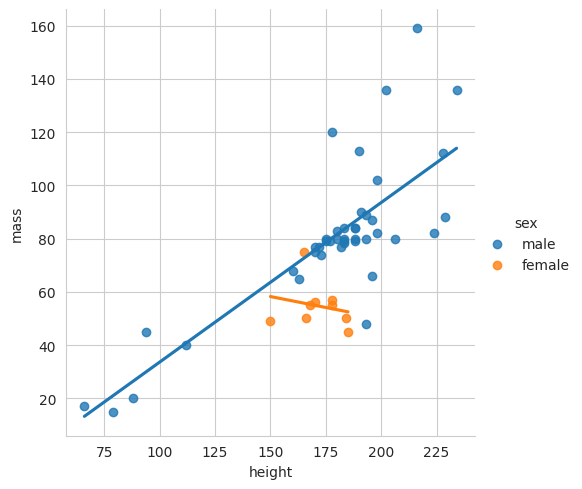

In [13]:
sns.lmplot(data=sw, x="height", y="mass", hue="sex", ci=None)

But it's time to unpack that quick plot that we previously made!

Let's take a moment and consider a fictional piecewise equation for male and female mass vs. height:

$$y = \begin{cases} 55 & \text{if female} \\ 75 & \text{if male} \end{cases}$$

Here is that fictional relationship:

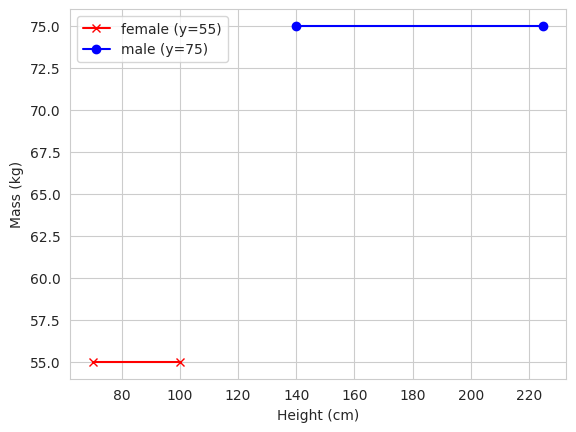

In [14]:
plt.plot([70,100], [55,55], 'rx-', label='female (y=55)')
plt.plot([140,225], [75,75],'bo-', label='male (y=75)')
plt.xlabel('Height (cm)')
plt.ylabel ('Mass (kg)')
plt.legend()

How can we turn that into a single equation regression model?

We first need to choose a _reference level_. 

We often do this alphabetically, so we take female as the reference level.

Now, what happens when we try to include males?

We can say that relative to our reference of y=55 for female, we move up by 20 kg for the males.

This allows us to write the two equations:

$$y = \begin{cases} 55 & \text{if female} \\ 75 & \text{if male} \end{cases}$$

as one:

$$y = 55 + 20 \times \mathbf{1}_{male}$$

That $\mathbf{1}_{male}$ is 1 in the case of the male category, so the equation for male is just:

$$y = 55 + 20 \times 1$$

$$y = 55 + 20$$

$$y = 75$$

And, in the case of female, the $\mathbf{1}_{male}$ is equal to 0, and we have:

$$y = 55 + 20 \times \mathbf{1}_{male}$$

$$y = 55 + 20 \times 0$$

$$y = 55$$

So, we've captured both of the piecewise equations in one, using 0 or 1 to represent the reference level and additional category, respectively!

**Bottom line:**

When you include a categorical variable, they get encoded as **dummy variables** (a.k.a. **indicator variables**). One level becomes the reference, and other levels get coefficients showing the difference from the reference.

## Categorical Predictors with `statsmodels`

In practical terms, we can again use `smf.ols` to accomplish the categorical prediction:

In [15]:
model_cat=smf.ols("mass ~ sex", data=sw).fit()
model_cat.params

Intercept      54.688889
sex[T.male]    25.530159
dtype: float64

**Interpretation:**

$$\widehat{mass} = 54.7 + 25.5 \times \mathbf{1}_{male}$$

When you see `sex[T.male]` ("T" stands for "Treatment." In statistics, we often compare a "treatment group" to a "reference group"), which is the coefficient to $\mathbf{1}_{male}$ in our equation, you just need to be aware of the _other_ implied category in the data in order to make the interpretation:

- Female characters weigh 54.7 kg on average
- Male characters are 25.5 kg heavier on average (54.7 + 25.5 = 80.2 kg)

In other words: sex does determine mass in our dataset (in addition to height).

And we can plot these results as well:

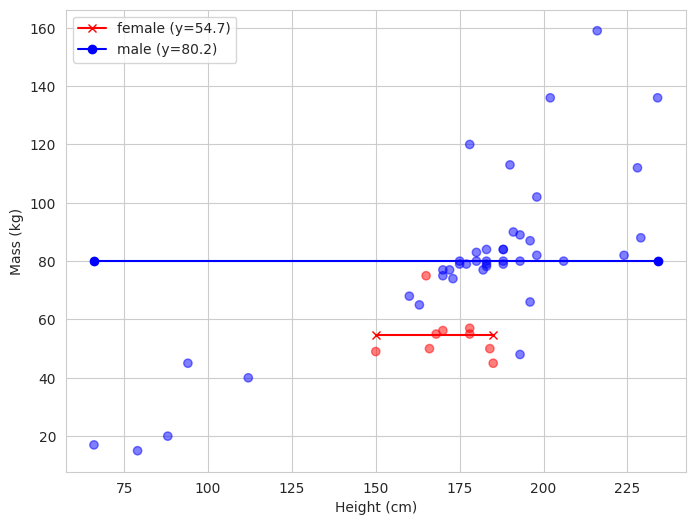

In [16]:
plt.figure(figsize=(8, 6))
plt.scatter(sw['height'], sw['mass'], color=sw['sex'].map({'female': 'red', 'male': 'blue'}), alpha=0.5)
plt.plot([sw[sw['sex'] == 'female']['height'].min(), sw[sw['sex'] == 'female']['height'].max()], [54.7, 54.7], 'rx-', label='female (y=54.7)')
plt.plot([sw[sw['sex'] == 'male']['height'].min(), sw[sw['sex'] == 'male']['height'].max()], [80.2, 80.2], 'bo-', label='male (y=80.2)')
plt.xlabel('Height (cm)')
plt.ylabel('Mass (kg)')
plt.legend()
plt.show()

But wait, this is just a complicated way of representing the two average masses of the different categorical sex values:

In [17]:
print(sw[sw["sex"] == "female"]["mass"].mean())
print(sw[sw["sex"] == "male"]["mass"].mean())

54.68888888888889
80.21904761904761


However, by putting the categorical predictors into the framework of regression equations we can combine them with numerical predictors to build richer models. Let's see how this works.

---
## Multiple Regression

We can include both numerical and categorical predictors in the same model using `+` in the formula. This lets us ask: "After accounting for sex, how does height affect mass?"

In [18]:
model_add = smf.ols('mass ~ height + sex', data=sw).fit()
model_add.params

Intercept     -46.053489
sex[T.male]    21.899593
height          0.587229
dtype: float64

### Understanding the Additive Model

Let's break down what we got:

$$\widehat{mass} = -46.1 + 0.59 \times height + 21.9 \times \mathbf{1}_{male}$$

This is called an **additive model** because we simply _add_ the effect of sex to the effect of height. The key insight is that the slope for height (0.59) is the same for both sexes—only the intercept changes.

**For females** ($\mathbf{1}_{male} = 0$):

$$\widehat{mass} = -46.1 + 0.59 \times height + 21.9 \times 0$$
$$\widehat{mass} = -46.1 + 0.59 \times height$$

**For males** ($\mathbf{1}_{male} = 1$):

$$\widehat{mass} = -46.1 + 0.59 \times height + 21.9 \times 1$$
$$\widehat{mass} = (-46.1 + 21.9) + 0.59 \times height$$
$$\widehat{mass} = -24.2 + 0.59 \times height$$

Notice that both equations have the **same slope** (0.59) but **different intercepts** (-46.1 for females, -24.2 for males). This means the lines are parallel!

**Interpretation:**
- For each additional cm in height, mass increases by 0.59 kg on average (regardless of sex)
- Male characters are 21.9 kg heavier than female characters of the same height

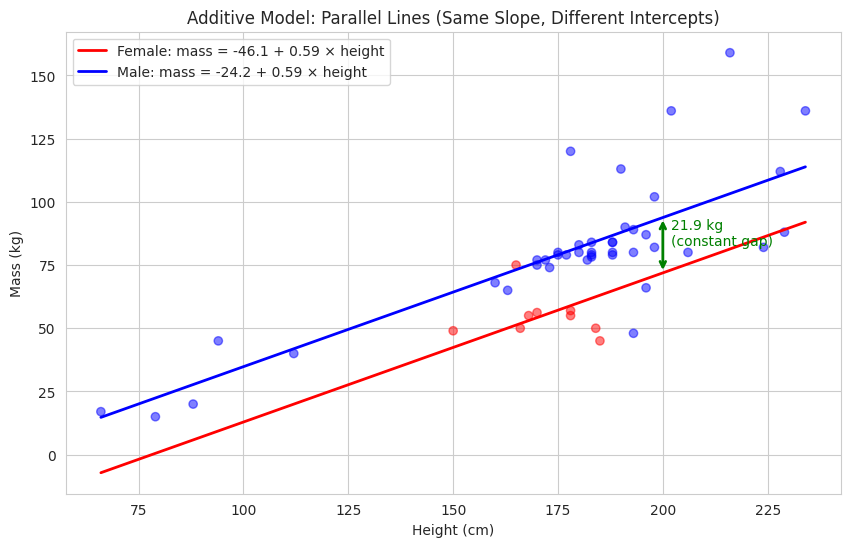

In [19]:
# Visualize the parallel lines (additive model)
plt.figure(figsize=(10, 6))

# Plot the data points
colors = sw['sex'].map({'female': 'red', 'male': 'blue'})
plt.scatter(sw['height'], sw['mass'], c=colors, alpha=0.5)

# Plot the parallel regression lines
height_range = np.linspace(sw['height'].min(), sw['height'].max(), 100)

# Female line: mass = -46.1 + 0.59 * height
female_line = -46.1 + 0.59 * height_range
plt.plot(height_range, female_line, 'r-', linewidth=2, label='Female: mass = -46.1 + 0.59 × height')

# Male line: mass = -24.2 + 0.59 * height
male_line = -24.2 + 0.59 * height_range
plt.plot(height_range, male_line, 'b-', linewidth=2, label='Male: mass = -24.2 + 0.59 × height')

# Add annotation showing the constant gap
plt.annotate('', xy=(200, -24.2 + 0.59*200), xytext=(200, -46.1 + 0.59*200),
            arrowprops=dict(arrowstyle='<->', color='green', lw=2))
plt.text(202, (-24.2 + 0.59*200 + -46.1 + 0.59*200)/2, '21.9 kg\n(constant gap)', fontsize=10, color='green')

plt.xlabel('Height (cm)')
plt.ylabel('Mass (kg)')
plt.title('Additive Model: Parallel Lines (Same Slope, Different Intercepts)')
plt.legend()
plt.show()

The green arrow shows that male characters are always predicted to be 21.9 kg heavier than female characters _at any height_. This is what "parallel lines" means—the gap between the groups is constant.

But is this assumption reasonable? Looking at the plot from earlier in the notebook, it seemed like the relationship between height and mass might be _different_ for males vs. females. The male trend line appeared steeper. 

What if we want to allow different slopes for different groups?

---
## Interaction Terms

An **interaction** allows the relationship between one predictor and the response to differ across levels of another predictor. In our case, this means the slope of the height-mass relationship can be different for males vs. females.

In statsmodels formula syntax:
- Use `:` for just the interaction term (e.g., `height:sex`)
- Use `*` for main effects plus interaction (e.g., `height * sex` is shorthand for `height + sex + height:sex`)

Let's fit a model with an interaction:

In [20]:
model_int=smf.ols("mass ~ height * sex", data=sw).fit()
model_int.params

Intercept              82.859291
sex[T.male]          -109.224200
height                 -0.164206
height:sex[T.male]      0.763874
dtype: float64

### Understanding the Interaction Model

The interaction model has four coefficients:

$$\widehat{mass} = 82.9 - 0.16 \times height - 109.2 \times \mathbf{1}_{male} + 0.76 \times height \times \mathbf{1}_{male}$$

This looks complicated! But let's break it down by substituting in the values for each sex.

**For females** ($\mathbf{1}_{male} = 0$):

$$\widehat{mass} = 82.9 - 0.16 \times height - 109.2 \times 0 + 0.76 \times height \times 0$$

The terms with $\mathbf{1}_{male}$ disappear:

$$\widehat{mass} = 82.9 - 0.16 \times height$$

**For males** ($\mathbf{1}_{male} = 1$):

$$\widehat{mass} = 82.9 - 0.16 \times height - 109.2 \times 1 + 0.76 \times height \times 1$$

Collecting the constant terms and the height terms:

$$\widehat{mass} = (82.9 - 109.2) + (-0.16 + 0.76) \times height$$

$$\widehat{mass} = -26.4 + 0.60 \times height$$

Now we can see clearly: **the two groups have different slopes!**

| Sex | Intercept | Slope |
|-----|-----------|-------|
| Female | 82.9 | -0.16 |
| Male | -26.4 | 0.60 |

**Interpretation:**
- For females, there's essentially no relationship between height and mass (slope ≈ 0)
- For males, each additional cm in height is associated with 0.60 kg more mass
- The `height:sex[T.male]` coefficient (0.76) tells us how much steeper the male slope is compared to the female slope

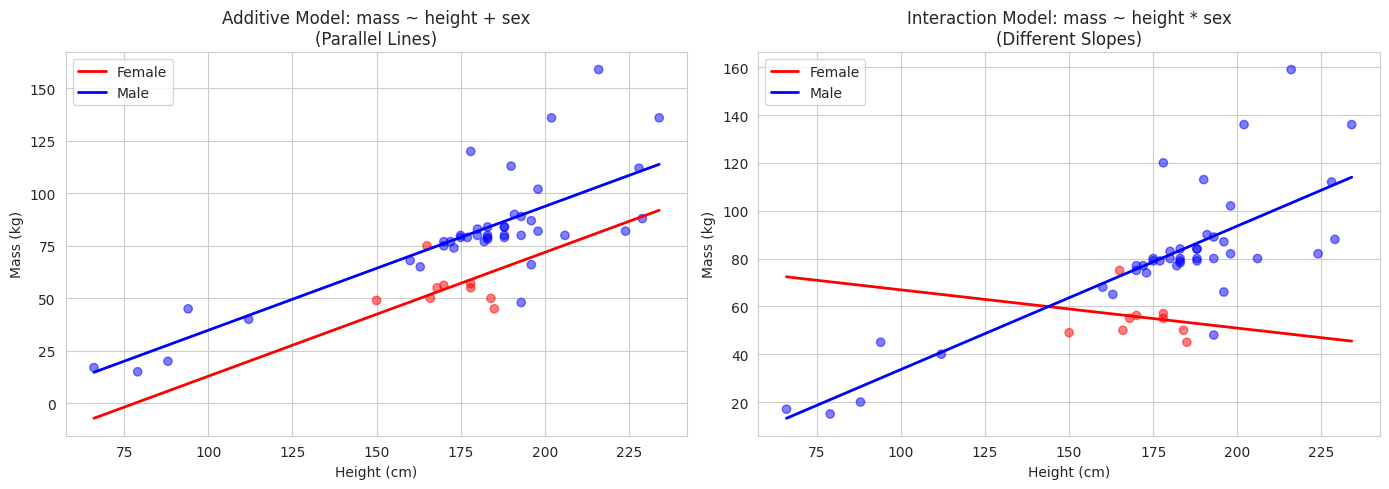

In [21]:
# Visualize the interaction model with equations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

height_range = np.linspace(sw['height'].min(), sw['height'].max(), 100)
colors = sw['sex'].map({'female': 'red', 'male': 'blue'})

# Left plot: Additive model (parallel lines)
axes[0].scatter(sw['height'], sw['mass'], c=colors, alpha=0.5)
axes[0].plot(height_range, -46.1 + 0.59 * height_range, 'r-', linewidth=2, label='Female')
axes[0].plot(height_range, -24.2 + 0.59 * height_range, 'b-', linewidth=2, label='Male')
axes[0].set_xlabel('Height (cm)')
axes[0].set_ylabel('Mass (kg)')
axes[0].set_title('Additive Model: mass ~ height + sex\n(Parallel Lines)')
axes[0].legend()

# Right plot: Interaction model (different slopes)
axes[1].scatter(sw['height'], sw['mass'], c=colors, alpha=0.5)
axes[1].plot(height_range, 82.9 - 0.16 * height_range, 'r-', linewidth=2, label='Female')
axes[1].plot(height_range, -26.4 + 0.60 * height_range, 'b-', linewidth=2, label='Male')
axes[1].set_xlabel('Height (cm)')
axes[1].set_ylabel('Mass (kg)')
axes[1].set_title('Interaction Model: mass ~ height * sex\n(Different Slopes)')
axes[1].legend()

plt.tight_layout()
plt.show()

Looking at these side-by-side:

- **Additive model (left)**: Forces both groups to have the same slope. The lines are parallel, with a constant 21.9 kg gap between them.
- **Interaction model (right)**: Allows each group to have its own slope. The female line is nearly flat, while the male line shows a clear positive relationship.

Which model is "better"? We'll return to this question shortly when we discuss model comparison.

---
## Model Types Summary

We've now seen four types of linear models. Here's a summary of how they differ:

| Model | Formula | What it does | Number of lines |
|-------|---------|--------------|-----------------|
| Single numerical | `y ~ x` | One regression line for all data | 1 line |
| Single categorical | `y ~ cat` | Separate mean for each group | Flat lines (one per group) |
| Additive | `y ~ x + cat` | Same slope, different intercepts | Parallel lines |
| Interaction | `y ~ x * cat` | Different slopes and intercepts | Non-parallel lines |

**When to use each:**

- **Single numerical**: When you only have one continuous predictor
- **Single categorical**: When you only want to compare group means (equivalent to a t-test for 2 groups or ANOVA for more)
- **Additive**: When you believe the effect of x is the same across all groups, but groups have different baseline levels
- **Interaction**: When you believe the effect of x differs across groups (the relationship depends on group membership)

---
## Making Predictions

One of the main uses of regression models is to make predictions for new observations. Once you've fit a model, you can use `.predict()` to estimate the response variable for any combination of predictor values.

Let's predict the mass for a 170 cm tall character, comparing males and females:

In [24]:
new_data= pd.DataFrame(
    {"height": [170, 170],
     "sex": ["female","male"]
     }
)

These predictions match what we calculated manually from the interaction model equations:
- Female at 170cm: $82.9 - 0.16 \times 170 = 82.9 - 25.5 \approx 55$ kg
- Male at 170cm: $-26.4 + 0.60 \times 170 = -26.4 + 102 \approx 76$ kg

We can also make predictions across a range of heights to visualize the model:

In [25]:
predictins = model_int.predict(new_data)

---
## Model Fit: R-squared

How do we know if our model is any good? One common measure is **R²** (R-squared), also called the **coefficient of determination**.

**Intuition:** R² answers the question: "How much of the variability in the response variable does our model explain?"

- **R² = 0**: The model explains none of the variability (predictions are no better than just using the mean)
- **R² = 1**: The model explains all of the variability (perfect predictions)
- **R² = 0.66**: The model explains 66% of the variability

**Adjusted R²** is a modified version that penalizes for adding more predictors. This is important because R² always increases (or stays the same) when you add more variables, even if those variables don't really help. Adjusted R² can decrease if you add unhelpful predictors.

Our interaction model has R² = 0.67, meaning about **67% of the variability in mass is explained by height and sex** (with their interaction). The remaining 33% is due to other factors we haven't measured, or random variation.

Is 0.67 "good"? It depends on the context:
- In physics or engineering, you might expect R² > 0.95
- In social sciences or biology, R² of 0.3-0.5 is often considered reasonable
- In economics or behavioral research, even R² of 0.1-0.2 can be meaningful

The key is to compare your model against alternatives and think about whether the explained variance is useful for your research question.

### Comparing Models

Let's compare all the models we've built. We'll look at three metrics:
- **R²**: Higher means more variance explained
- **Adjusted R²**: Higher means more variance explained (accounting for model complexity)
- **AIC** (Akaike Information Criterion): Lower means better balance of fit and complexity

**What do we learn from this comparison?**

1. **Sex alone** (R² = 0.12) explains less variance than **height alone** (R² = 0.56). Height is a stronger predictor of mass.

2. **Combining height + sex** (R² = 0.66) is better than either predictor alone. Both variables contribute useful information.

3. **Adding the interaction** (R² = 0.67) provides only a small improvement over the additive model. The adjusted R² is actually slightly lower (0.65 vs 0.64), suggesting the added complexity of the interaction may not be worth it.

4. Looking at **AIC** (lower is better): the additive and interaction models are very close (434.8 vs 434.6). This confirms that the interaction term provides minimal benefit.

**Conclusion:** For this dataset, the additive model `mass ~ height + sex` might be the best choice—it captures most of the relationship while remaining simpler to interpret.

---
## Model Selection Criteria

When choosing between models, we have several metrics to consider:

| Metric | What it measures | Criterion | Notes |
|--------|------------------|-----------|-------|
| **R²** | Variance explained | Higher is better | Always increases with more predictors |
| **Adjusted R²** | Variance explained (penalized) | Higher is better | Can decrease if predictors don't help |
| **AIC** | Fit vs. complexity trade-off | Lower is better | Penalizes extra parameters |
| **BIC** | Fit vs. complexity trade-off | Lower is better | Stronger penalty than AIC |
| **p-value** | Statistical significance | < 0.05 typically | For individual coefficients |

**Rules of thumb:**

- **Parsimony**: When models are similar in fit, prefer the simpler one (fewer predictors)
- **AIC difference < 2**: Models are essentially equivalent
- **AIC difference 2-10**: Some evidence for the lower-AIC model
- **AIC difference > 10**: Strong evidence for the lower-AIC model

In our case, the additive and interaction models have AIC values within 1 of each other, so they're essentially equivalent in terms of fit. The additive model is simpler, so it might be preferred.

---
## Summary

### Key Concepts

| Concept | Description |
|---------|-------------|
| **Linear model** | Predicts a response variable as a linear combination of predictors |
| **Dummy variable** | Binary (0/1) encoding for categorical predictors |
| **Reference level** | The category encoded as 0; other categories are compared to it |
| **Additive model** | Predictors have independent effects (parallel lines) |
| **Interaction** | Effect of one predictor depends on another (different slopes) |
| **R²** | Proportion of variance explained by the model |

### Statsmodels Code Reference

| Task | Code |
|------|------|
| Fit model | `smf.ols('y ~ x', data).fit()` |
| Get coefficients | `model.params` |
| Full summary | `model.summary()` |
| Predictions | `model.predict(new_data)` |
| R-squared | `model.rsquared` |
| Adjusted R² | `model.rsquared_adj` |
| AIC | `model.aic` |

### Formula Syntax

| Formula | Model type | Result |
|---------|------------|--------|
| `y ~ x` | Single predictor | One regression line |
| `y ~ cat` | Categorical only | Group means |
| `y ~ x + cat` | Additive | Parallel lines |
| `y ~ x * cat` | Interaction | Different slopes |
| `y ~ x + cat + x:cat` | Same as above | Explicit interaction term |

Now you're ready to practice with the OLS exercises!